# T2FPharm Study Manager

The `t2fpharm_study` package provides a convenient way
to perform pharmacophore generation and analysis on a series of structures.

In [1]:
import t2fpharm_study

First, create a `t2fpharm_study.manager.Manager` object.
You can provide a path to a directory where input/output data are stored.
If not provided, the default directory at `t2fpharm/study/pkg/src/t2fpharm_study/data` is used.

In [2]:
manager = t2fpharm_study.manager()

The manager then provides methods to access all inputs, intermediate results, and outputs.

## Inputs

### Evaluation dataset

In [3]:
manager.dataset

,group_id,group_name,uniprot_id,pdb_id,is_ref,chain_id,ligand_res_name,ligand_chain_id,ligand_res_seq
pdb_id,,,,,,,,,
1AQ1,CDK2,Cyclin-dependent kinase 2,P24941,1AQ1,True,A,STU,A,299
1DI8,CDK2,Cyclin-dependent kinase 2,P24941,1DI8,False,A,DTQ,A,500
1E1V,CDK2,Cyclin-dependent kinase 2,P24941,1E1V,False,A,CMG,A,401
1E1X,CDK2,Cyclin-dependent kinase 2,P24941,1E1X,False,A,NW1,A,401
1FIN,CDK2,Cyclin-dependent kinase 2,P24941,1FIN,False,A,ATP,A,299
1FVV,CDK2,Cyclin-dependent kinase 2,P24941,1FVV,False,A,107,A,501
1DRF,DHFR,Dihydrofolate reductase,P00374,1DRF,True,A,FOL,A,187
1BOZ,DHFR,Dihydrofolate reductase,P00374,1BOZ,False,A,PRD,A,400
1DLR,DHFR,Dihydrofolate reductase,P00374,1DLR,False,A,MXA,A,188


### Pocket Parameters

In [4]:
manager.pocket_params

{'grid_spacing': 0.3,
 'ligand_radii_offset': 2.7,
 'opening_radius': 1,
 'erosion_radius': 0}

### Field Parameters

In [5]:
manager.field_params

{'ligand_types': ['HD', 'C', 'OA', 'e-', 'e+'],
 'smooth': 0.5,
 'dielectric': -0.1465}

### Job Inputs

In [29]:
manager.job_inputs()

,job_name,job_idx,best_per_point,center_type,filter_function,filter_gaussian_sigma,filter_gaussian_sigma_mult,filter_gaussian_sigma_mult_idx,filter_radius,filter_radius_mult,...,min_neighbors_list_length,min_neighbors_list_length_idx,min_neighbors_start_percent,min_neighbors_start_percent_idx,priority_factor,priority_factor_idx,threshold_percentile,threshold_percentile_idx,threshold_value,threshold_value_idx
0,grid_search-cnn-1,0,True,average,None,NaN,NaN,NaN,NaN,NaN,...,5.0,0.0,1.0,0.0,NaN,NaN,1.0,0.0,0,0
1,grid_search-cnn-1,1,True,mean,None,NaN,NaN,NaN,NaN,NaN,...,5.0,0.0,1.0,0.0,NaN,NaN,1.0,0.0,0,0
2,grid_search-cnn-1,2,True,midpoint,None,NaN,NaN,NaN,NaN,NaN,...,5.0,0.0,1.0,0.0,NaN,NaN,1.0,0.0,0,0
3,grid_search-cnn-1,3,True,average,None,NaN,NaN,NaN,NaN,NaN,...,5.0,0.0,1.0,0.0,NaN,NaN,1.0,0.0,0,0
4,grid_search-cnn-1,4,True,mean,None,NaN,NaN,NaN,NaN,NaN,...,5.0,0.0,1.0,0.0,NaN,NaN,1.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32811,grid_search-lp-2,2795,NaN,NaN,gaussian,"{'C': 1.7, 'HD': 1.2, 'OA': 1.55, 'e+': 2.22, ...",1.0,3.0,"{'C': 1.7, 'HD': 1.2, 'OA': 1.55, 'e+': 2.22, ...",1.0,...,NaN,NaN,NaN,NaN,"{'C': 1, 'HD': 1, 'OA': 1.0, 'e+': 1.0, 'e-': ...",0.0,NaN,NaN,0,0
32812,grid_search-lp-2,2796,NaN,NaN,gaussian,"{'C': 1.7, 'HD': 1.2, 'OA': 1.55, 'e+': 2.22, ...",1.0,3.0,"{'C': 1.7, 'HD': 1.2, 'OA': 1.55, 'e+': 2.22, ...",1.0,...,NaN,NaN,NaN,NaN,"{'C': 1, 'HD': 1, 'OA': 1.0, 'e+': 0.5, 'e-': ...",1.0,NaN,NaN,0,0
32813,grid_search-lp-2,2797,NaN,NaN,gaussian,"{'C': 1.7, 'HD': 1.2, 'OA': 1.55, 'e+': 2.22, ...",1.0,3.0,"{'C': 1.7, 'HD': 1.2, 'OA': 1.55, 'e+': 2.22, ...",1.0,...,NaN,NaN,NaN,NaN,"{'C': 1, 'HD': 1, 'OA': 0.7, 'e+': 0.5, 'e-': ...",2.0,NaN,NaN,0,0
32814,grid_search-lp-2,2798,NaN,NaN,gaussian,"{'C': 1.7, 'HD': 1.2, 'OA': 1.55, 'e+': 2.22, ...",1.0,3.0,"{'C': 1.7, 'HD': 1.2, 'OA': 1.55, 'e+': 2.22, ...",1.0,...,NaN,NaN,NaN,NaN,"{'C': 1, 'HD': 1, 'OA': 1.0, 'e+': 0.3, 'e-': ...",3.0,NaN,NaN,0,0


## Intermediate Results

For each PDB ID in the evaluation dataset, intermediate results can be accessed:

### Raw PDB

The `pdb_raw()` method returns a `PDBFile` object containing all data in the PDB file.

In [7]:
manager.pdb_raw("1aq1")

Each PDB record is accessible by its name; for example:

In [8]:
manager.pdb_raw("1aq1").dbref

,id_code,chain_id,seq_begin,insert_begin,seq_end,insert_end,database,db_accession,db_id_code,db_seq_begin,db_ins_begin,db_seq_end,db_ins_end
chain_id,,,,,,,,,,,,,
A,1AQ1,A,1,,298,,UNP,P24941,CDK2_HUMAN,1,,298,


In [9]:
manager.pdb_raw("1aq1").seqres

,chain_id,num_res,res_name
chain_id,,,
A,A,298,"[MET, GLU, ASN, PHE, GLN, LYS, VAL, GLU, LYS, ..."


In [10]:
manager.pdb_raw("1aq1").het

,het_id,chain_id,seq_num,i_code,num_het_atoms,text
het_id,,,,,,
STU,STU,A,299,,35,


### Receptor–Ligand Complex

The `complex()` method returns a `t2fpharm.system.System` object corresponding to the fixed and aligned PDB structure.

In [11]:
manager.complex("1aq1")

In [12]:
manager.complex("1aq1").display()

ThemeManager()

NGLWidget(gui_style='ngl')

We can visually confirm that all PDB structures within a group are aligned:

In [16]:
group_id = "CDK2"
ref_pdb_id = manager.ref_pdb_id(group_id=group_id)
nonref_pdb_ids = manager.group_pdb_ids(group_id=group_id, include_ref=False)
viewer = manager.complex(ref_pdb_id).display()
for nonref_pdb_id in nonref_pdb_ids:
    manager.complex(nonref_pdb_id).display(nglwidget=viewer)
viewer

NGLWidget(gui_style='ngl')

### Receptor

Similarly, the isolated receptor can be accessed by the `receptor()` method:

In [15]:
manager.receptor("1aq1")

### Pocket

The `pocket()` method returns a `t2fpharm.pocket.Pocket` object for a given PDB ID:

In [18]:
manager.pocket("1aq1").display()

NGLWidget(gui_style='ngl')

### Field

The `field()` method returns a `t2fpharm.field.Field` object containing the AutoGrid energy values:

In [21]:
manager.field("1aq1").tensor.shape

(5, 77, 80, 77)

### Ligand Pharmacophore

The `ligand_pharmacophore()` methods returns a `t2fpharm.pharm.Pharmacophore` object for the ligand in the complex:

In [22]:
manager.ligand_pharmacophore("1aq1").features

,instance,type,label,center,radius
0,0,OA,1,"[2.145, 30.733, 5.82]",0
1,0,HD,1,"[0.774, 32.543, 6.843]",0
2,0,HD,2,"[2.945, 24.265, 12.75]",0
3,0,C,1,"[-3.112, 27.011, 11.173]",0
4,0,C,2,"[0.774, 29.374, 7.329]",0
5,0,C,3,"[2.646, 27.528, 6.811]",0
6,0,C,4,"[-4.061, 27.944, 11.468]",0
7,0,C,5,"[-4.015, 29.25, 10.895]",0
8,0,C,6,"[-0.312, 29.613, 8.017]",0
9,0,C,7,"[1.478, 28.081, 7.37]",0


In [23]:
manager.ligand_pharmacophore("1aq1").display()

NGLWidget(gui_style='ngl')

The original PLIP data for the ligand pharmacophore can be accessed as well:

In [24]:
manager.ligand_pharmacophore("1aq1").extra["plip"].all

,type,l_res_name,l_res_seq,l_chain_id,l_serial,l_type,l_position,r_res_name,r_res_seq,r_chain_id,r_serial,r_type,r_position,r_is_d,is_sidechain,h_position,dist_a_h,dist_a_d,angle,dist
0,hbond,STU,299,A,4888,O2,"[2.145, 30.733, 5.82]",LEU,83,A,1355,Nam,"[3.996, 32.392, 4.962]",True,False,"[3.658, 31.768, 5.896]",1.834713,2.629571,120.313216,<NA>
1,hbond,STU,299,A,4885,Nam,"[0.246, 31.488, 6.873]",GLU,81,A,1325,O2,"[0.245, 33.785, 5.361]",False,False,"[0.774, 32.543, 6.843]",2.004677,2.749973,117.038492,<NA>
2,hbond,STU,299,A,4905,N3,"[2.19, 23.51, 12.249]",GLN,131,A,2156,O2,"[2.191, 25.474, 14.327]",False,False,"[2.945, 24.265, 12.75]",2.125353,2.859262,116.886755,<NA>
3,hydrophobic,STU,299,A,4874,<NA>,"[-3.112, 27.011, 11.173]",VAL,18,A,279,<NA>,"[-4.294, 25.886, 7.56]",<NA>,<NA>,None,<NA>,<NA>,<NA>,3.964406
4,hydrophobic,STU,299,A,4869,<NA>,"[0.774, 29.374, 7.329]",ALA,31,A,489,<NA>,"[-1.403, 30.583, 4.255]",<NA>,<NA>,None,<NA>,<NA>,<NA>,3.95607
5,hydrophobic,STU,299,A,4889,<NA>,"[2.646, 27.528, 6.811]",ILE,10,A,176,<NA>,"[0.559, 26.654, 3.873]",<NA>,<NA>,None,<NA>,<NA>,<NA>,3.708273
6,hydrophobic,STU,299,A,4876,<NA>,"[-4.061, 27.944, 11.468]",LYS,33,A,524,<NA>,"[-7.433, 27.939, 9.453]",<NA>,<NA>,None,<NA>,<NA>,<NA>,3.928185
7,hydrophobic,STU,299,A,4878,<NA>,"[-4.015, 29.25, 10.895]",PHE,80,A,1316,<NA>,"[-5.757, 31.992, 8.704]",<NA>,<NA>,None,<NA>,<NA>,<NA>,3.918368
8,hydrophobic,STU,299,A,4870,<NA>,"[-0.312, 29.613, 8.017]",LEU,134,A,2212,<NA>,"[2.133, 30.923, 10.197]",<NA>,<NA>,None,<NA>,<NA>,<NA>,3.527963
9,hydrophobic,STU,299,A,4868,<NA>,"[1.478, 28.081, 7.37]",LEU,134,A,2216,<NA>,"[3.732, 28.976, 10.133]",<NA>,<NA>,None,<NA>,<NA>,<NA>,3.676372


NGLWidget(gui_style='ngl')

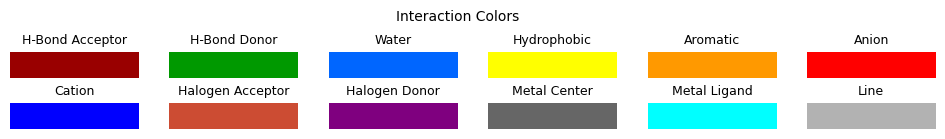

In [27]:
viewer, legend = manager.ligand_pharmacophore("1aq1").extra["plip"].display()
manager.complex("1aq1").display(nglwidget=viewer)

## Modeler

For each PDB ID, you can get the corresponding `t2fpharm.modeler.Modeler` object to generate pharmacophores:

In [28]:
manager.modeler("1aq1")

You can call the `run()` method to run a specific job defined in the input file for all structures,
or you can call the `run_all()` method to run all jobs.

## Outputs

After running the jobs, the outputs can be accessed from the manager as well.

### Jobs Summary

A summary of each job can be accessed using the `job_summary()` method:

In [30]:
manager.job_summary()

,job_name,job_idx,group_id,pdb_id,t_all-d_max-l_all,t_all-d_max-l_self,t_all-d_mean-l_all,t_all-d_mean-l_self,t_all-d_median-l_all,t_all-d_median-l_self,...,t_e--dp_lt3-l_self,t_e--n,t_e--nl_all,t_e--nl_self,t_e--r_max,t_e--r_mean,t_e--r_min,t_e--v_max,t_e--v_mean,t_e--v_min
0,grid_search-cnn-1,0,A2AR,2YDO,10.923259,10.923259,7.864268,8.152646,7.294803,7.57666,...,<NA>,0,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,grid_search-cnn-1,0,A2AR,2YDV,12.378593,12.378593,5.762719,6.67163,3.487594,3.355216,...,<NA>,0,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,grid_search-cnn-1,0,A2AR,3EML,9.321838,8.410725,5.460765,5.23857,6.200125,5.62704,...,<NA>,0,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,grid_search-cnn-1,0,CDK2,1AQ1,13.532287,11.106523,4.363998,4.715949,3.39119,1.542147,...,<NA>,0,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,grid_search-cnn-1,0,CDK2,1DI8,13.159108,9.094387,5.006755,3.695116,4.583102,2.300074,...,<NA>,0,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1050107,grid_search-lp-2,2799,THROM,1D6W,6.606584,4.219077,2.70355,2.593393,2.674928,2.798759,...,<NA>,11,0,0,<NA>,<NA>,<NA>,-0.078,-0.563727,-1.073
1050108,grid_search-lp-2,2799,THROM,1D9I,5.75834,4.553831,2.405247,2.839308,2.426732,2.779683,...,<NA>,15,0,0,<NA>,<NA>,<NA>,0.003,-0.522867,-1.252
1050109,grid_search-lp-2,2799,THROM,1DWD,6.753472,6.037713,2.875923,3.027104,2.769015,2.431123,...,<NA>,15,0,0,<NA>,<NA>,<NA>,-0.079,-0.648667,-1.285
1050110,grid_search-lp-2,2799,THROM,1FPC,6.173364,3.213011,2.336191,1.962085,1.931975,2.297043,...,<NA>,10,0,0,<NA>,<NA>,<NA>,-0.048,-0.5389,-1.393


### Pharmacophore

The `job_pharmacophore()` method returns a `t2fpharm.pharm.Pharmacophore` object for a specific PDB ID and job:

In [32]:
manager.job_pharmacophore(job_name="grid_search-lp-2", pdb_id="1aq1", job_idx=2799).features

,instance,type,label,center,radius,value
0,0,HD,"(62, 46, 14)","[7.969500064849852, 27.854500961303707, 2.8144...",1.2,-0.397
1,0,C,"(34, 44, 42)","[-0.43049993515014684, 27.25450096130371, 11.2...",1.7,-0.378
2,0,HD,"(44, 32, 43)","[2.569500064849853, 23.65450096130371, 11.5144...",1.2,-0.363
3,0,C,"(38, 39, 33)","[0.7695000648498542, 25.75450096130371, 8.5144...",1.7,-0.359
4,0,C,"(33, 35, 40)","[-0.7304999351501458, 24.55450096130371, 10.61...",1.7,-0.35
...,...,...,...,...,...,...
77,0,HD,"(51, 41, 30)","[4.669500064849853, 26.354500961303707, 7.6144...",1.2,-0.02
78,0,e+,"(47, 13, 46)","[3.4695000648498535, 17.954500961303708, 12.41...",2.22,-0.063
79,0,e-,"(53, 29, 51)","[5.2695000648498524, 22.75450096130371, 13.914...",2.8,-0.041
80,0,HD,"(36, 47, 28)","[0.1695000648498528, 28.15450096130371, 7.0144...",1.2,-0.007


### Matches

The `job_matches()` method returns a `pandas.DataFrame` containing matching details between a T2F pharmacophore and its corresponding ligand pharmacophores:

In [33]:
manager.job_matches(job_name="grid_search-lp-2", pdb_id="1aq1", job_idx=2799)

,type,ligand_label,target_label,distance,ligand_pdb_id,target_pdb_id,job_idx
0,OA,1,"(46, 50, 26)",2.054359,1AQ1,1AQ1,2799
1,HD,1,"(32, 58, 37)",3.561820,1AQ1,1AQ1,2799
2,HD,2,"(44, 32, 43)",1.428345,1AQ1,1AQ1,2799
3,C,1,"(30, 40, 42)",1.763932,1AQ1,1AQ1,2799
4,C,2,"(35, 43, 36)",3.319850,1AQ1,1AQ1,2799
5,C,3,"(38, 39, 33)",3.093293,1AQ1,1AQ1,2799
6,C,4,"(30, 40, 42)",3.088980,1AQ1,1AQ1,2799
7,C,5,"(30, 40, 42)",3.999892,1AQ1,1AQ1,2799
8,C,6,"(35, 43, 36)",3.008914,1AQ1,1AQ1,2799
9,C,7,"(38, 39, 33)",2.687834,1AQ1,1AQ1,2799
